In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/StudentsPerformance.csv")

In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df['Total Score'] = (df['math score'] + df['writing score'] + df['reading score'])

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [16]:
df['Average Score'] = (df['Total Score'] / 3)

**Does parental education affect scores?**

In [17]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Avegare Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333,76.333333


Factor Analysis Question 1

Does parental education affect scores?

In [18]:
parent_score = df.groupby(
    "parental level of education"
)["Average Score"].mean().sort_values()

print(parent_score)

parental level of education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: Average Score, dtype: float64


In [15]:
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Total Score', 'Avegare Score'],
      dtype='object')


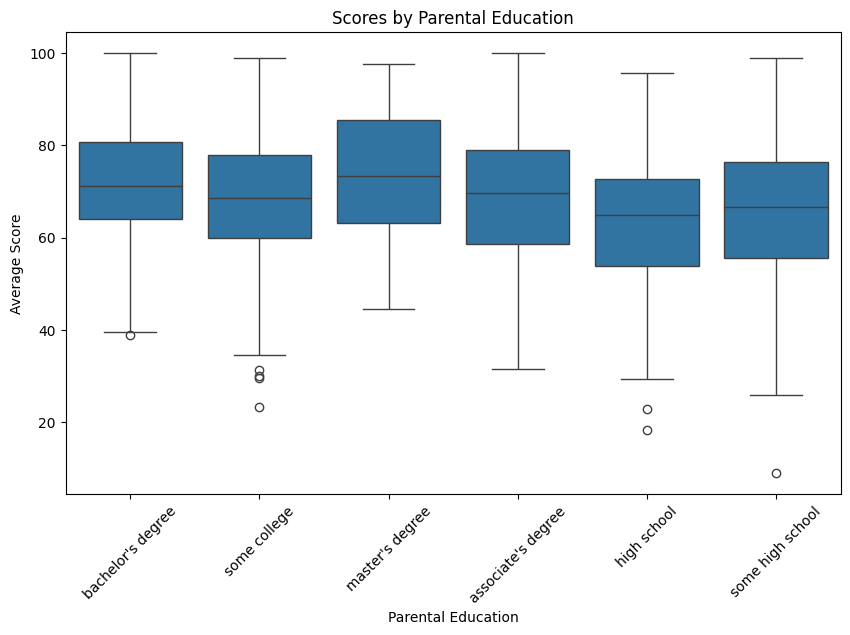

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='parental level of education',
    y='Average Score',
    data=df
)

plt.xticks(rotation=45)
plt.title("Scores by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Average Score")

plt.savefig("boxplot.png")
plt.show()

Factor Analysis Question 2

Does test preparation help?

In [20]:
df.groupby(
    "test preparation course"
)["Average Score"].mean()



,Average Score
test preparation course,
completed,72.669460
none,65.038941


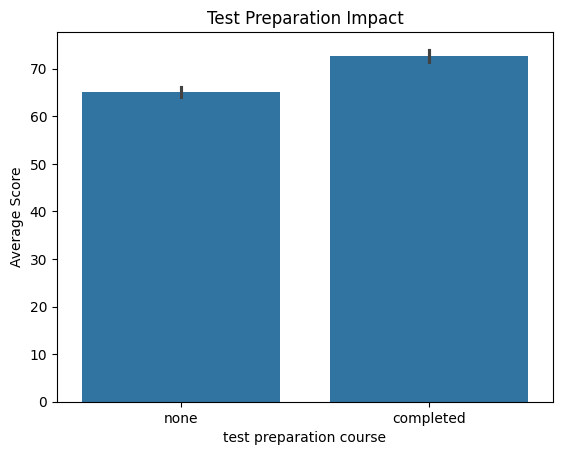

In [41]:
sns.barplot(
    x='test preparation course',
    y='Average Score',
    data=df
)


plt.savefig("barplot.png")
plt.title("Test Preparation Impact")
plt.show()

Factor Analysis Question 3

Correlation Between Subjects

In [22]:
corr = df[
    ["math score",
     "reading score",
     "writing score"]
].corr()

print(corr)

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


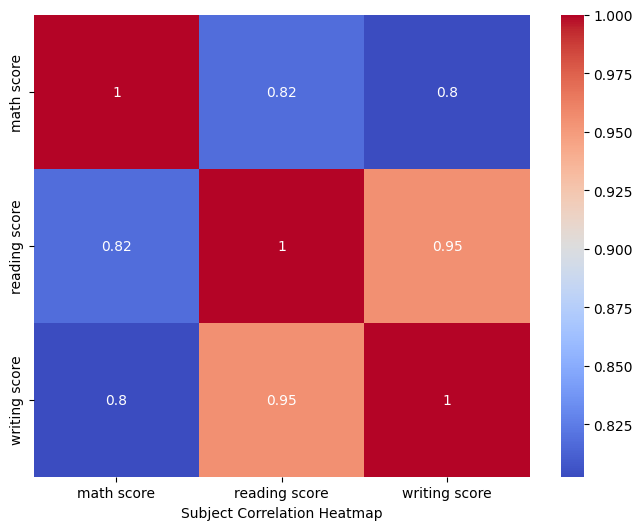

In [42]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.xlabel("Subject Correlation Heatmap")

plt.savefig("heatmap.png")
plt.show()

Factor Analysis Question 4

Which gender performs better?

In [25]:
gender_perform = df.groupby("gender")[
[
"math score",
"reading score",
"writing score"
]
].mean()

print(gender_perform)

        math score  reading score  writing score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


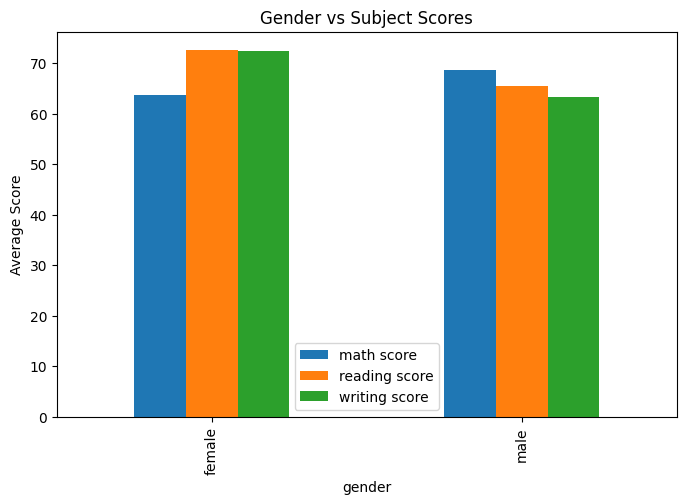

In [44]:
gender_perform.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Gender vs Subject Scores")
plt.ylabel("Average Score")

plt.savefig("genderbarplot.png")
plt.show()

Factor Analysis Question 5

Distribution of Total Scores

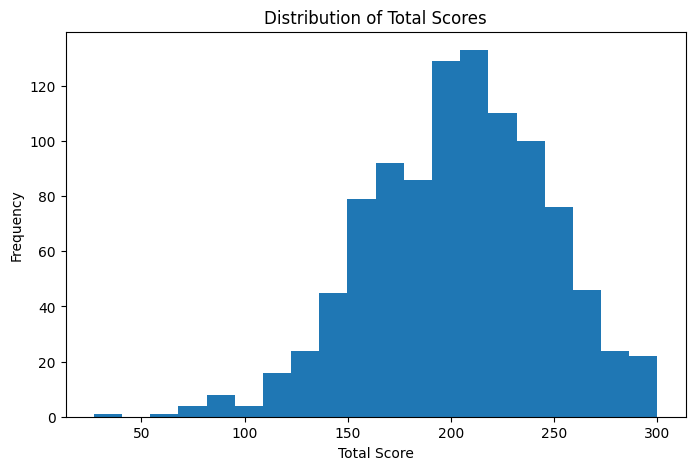

In [45]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Total Score"],
    bins=20
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Frequency")

plt.savefig("histplot.png")
plt.show()

Scatter Chart

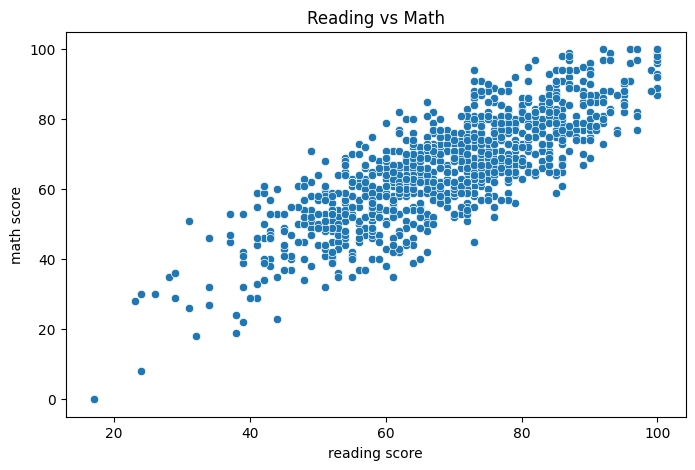

In [47]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='reading score',
    y='math score',
    data=df
)

plt.title("Reading vs Math")

plt.savefig("scatterplot.png")
plt.show()

At-Risk Student Segmentation

In [30]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Avegare Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333,76.333333


In [31]:
Total Score < 50

SyntaxError: invalid syntax (4126979259.py, line 1)

In [32]:
df["At Risk"] = (
    (df["math score"] < 50) |
    (df["reading score"] < 50) |
    (df["writing score"] < 50)
)

In [33]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Avegare Score,Average Score,At Risk
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,72.666667,False
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,82.333333,False
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,92.666667,False
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,49.333333,True
4,male,group C,some college,standard,none,76,78,75,229,76.333333,76.333333,False


In [34]:
df['At Risk'].value_counts()

,count
At Risk,
False,812
True,188


In [35]:
risk_percent = (
    df["At Risk"].mean()*100
)

print(risk_percent)

18.8


In [36]:
df.groupby(
    "gender"
)["At Risk"].mean()*100

,At Risk
gender,
female,17.181467
male,20.539419


In [38]:
df.groupby(
    "parental level of education"
)["At Risk"].mean()*100

,At Risk
parental level of education,
associate's degree,14.864865
bachelor's degree,13.559322
high school,25.000000
master's degree,10.169492
some college,16.814159
some high school,25.698324


In [39]:
df.groupby('test preparation course')['At Risk'].mean()*100

,At Risk
test preparation course,
completed,10.055866
none,23.676012


In [49]:
from google.colab import files
files.download('boxplot.png')
files.download('barplot.png')
files.download('heatmap.png')
files.download('genderbarplot.png')
files.download('histplot.png')
files.download('scatterplot.png')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>